### CSV Course Specifications

This is a demonstration of the course specifications linear regression algorithm using a CSV for input. This allows students to use larger data sets.

This can also be viewed as a Python script in [5.export_import.py](5.export_import.py.) and [5.test_import.py](5.test_import.py).

#### Step 1

Load the required dependencies including [pickle](https://docs.python.org/3/library/pickle.html) the native Python library for serialising data objects:

> [!Caution]
> The pickle module is not secure. Only unpickle data you trust.

In [ ]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import pickle

####  Step 2
- Open and parse the CSV file and store the data as variable array objects.

In [15]:
training_data = pd.read_csv("course_specifications_data.csv", delimiter=",")
x = np.array(training_data["events_completed"], dtype=float)
y = np.array(training_data["average"], dtype=float)

#### Optional Step

By printing the number of training examples and displaying the first few rows of data, I can confirm that the data has been parsed correctly and that the feature and target columns contain the correct numerical values. This inspection also helps identify any potential issues early on, such as missing values, incorrect data types, or unexpected formatting.

In [4]:
m = len(x)
print(f"Number of training examples is: {m}")
table = pd.DataFrame({
    training_data.columns[0]: x.flatten(),  # Flatten x for easy display
    training_data.columns[1]: y
})
print(table.head())

Number of training examples is: 9715
   events_completed   average
0               2.0  0.718471
1               1.0  0.456221
2               1.0  0.353376
3               2.0  0.314862
4               1.0  0.462972


#### Step 3

In this step, I load the previously trained model, but Instead of storing the full machine‑learning model object, the file contains only the three parameters a, b, and c that define the exponential function used during training. These parameters represent the learned behaviour of the model and allow me to reconstruct the exact function easily. I then print the parameters to make sure they match up. 


In [5]:
filename = "my_saved_poly_v3.pkl"
model_data = pickle.load(open(filename, "rb"))
a, b, c = model_data["a"], model_data["b"], model_data["c"]


# Reconstruct the exponential function
def exp_func(x, a, b, c):
    return a * np.exp(-b * x) + c


print(f"Model loaded: a={a:.4f}, b={b:.4f}, c={c:.4f}")

Model loaded: a=0.3163, b=0.0203, c=0.1128


#### Step 4

In this step, I confirm that the trained model has already been saved to a file so it can be reused during deployment.

In [6]:
# Model is already saved as my_saved_poly_v3.pkl - no need to re-save
print(f"Model is saved as: {filename}")
print(f"Parameters: a={a:.4f}, b={b:.4f}, c={c:.4f}")

Model is saved as: my_saved_poly_v3.pkl
Parameters: a=0.3163, b=0.0203, c=0.1128


#### Step 5

This step demonstrates how the saved model can be used to make predictions in a separate Python environment. By loading the stored parameters and reconstructing the exponential function, I can compute a predicted average score for any given number of events completed. In this example, I input a value of 4, and the model outputs the corresponding predicted performance.

In [7]:
# Load model and make a prediction
predict = 4
result = exp_func(predict, a, b, c)
print(f"Predicted average for {predict} events completed: {result:.4f}")

Predicted average for 4 events completed: 0.4045


#### Optional Step

This optional step creates a visual comparison between the training data and the fitted exponential model. The red scatter points represent the actual training data, while the blue line shows the model’s predicted values across the full range of events completed.

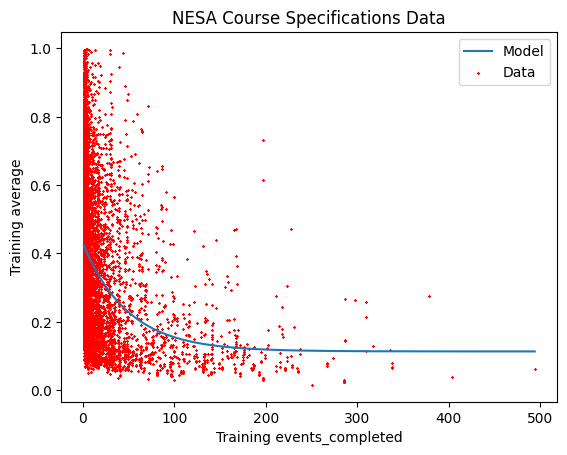

In [8]:
x_sorted = np.sort(x)
y_pred = exp_func(x_sorted, a, b, c)
plt.plot(x_sorted, y_pred, label="Model")
plt.scatter(x, y, marker='x', c='r', s=1, label="Data")
plt.title("NESA Course Specifications Data")
plt.ylabel(f'Training {training_data.columns[1]}')
plt.xlabel(f'Training {training_data.columns[0]}')
plt.legend()
plt.show()

#### Optional Step

Here, I extend the previous visualisation by adding a specific prediction point to the graph. After re-generating the smooth model curve using evenly spaced x‑values, I compute the predicted average for a chosen input (in this case, 4 events completed) and highlight that point on the plot with a distinct marker. An annotation is added to clearly display the predicted value.

This visualisation serves two purposes: first, it demonstrates how the model can be used to make real‑time predictions for any input value, and secondly, it produces a clean, informative graph that can be saved as an image file (graph.png) for use in external applications, such as a Flask API or a user interface.

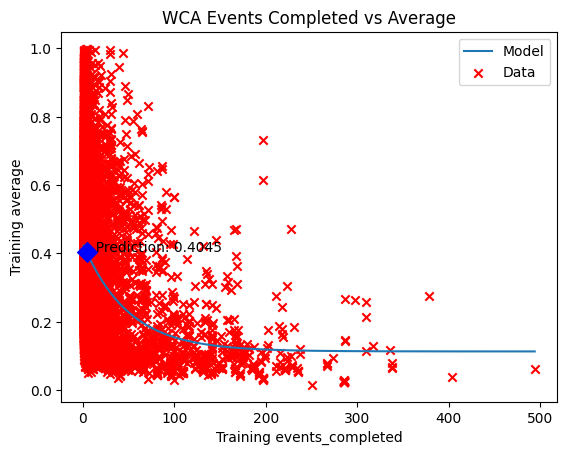

In [9]:
x_line = np.linspace(min(x), max(x), 200)
y_line = exp_func(x_line, a, b, c)

predict_val = 4
y_prediction = exp_func(predict_val, a, b, c)

plt.plot(x_line, y_line, label="Model")
plt.scatter(x, y, marker="x", c="r", label="Data")
plt.scatter(predict_val, y_prediction, marker="D", c="blue", zorder=10, s=100)
plt.text(predict_val, y_prediction, f"  Prediction: {y_prediction:.4f}")
plt.title("WCA Events Completed vs Average")
plt.ylabel(f"Training {training_data.columns[1]}")
plt.xlabel(f"Training {training_data.columns[0]}")
plt.legend()
plt.savefig("graph.png")
plt.show()

### Range

This section furhters the model deployment process by estimating a prediction range for the input value rather than a single predicted one. Instead of returning only one output for a given number of events completed, this code calculates a 10th–90th percentile band based on any real data points nearby, which provides a more realistic value due to the klower accuracy of this model, increaseing understanding of the uncertainty and natural variation in the dataset.

It first generates a smooth sequence of x‑values (x_line) across the full range of events completed which allows the model to produce a continuous prediction curve rather than isolated points. 

Before calculating the prediction range, the code first trims the data:
- Removes the top 1% of unusually high values
- Removes the bottom 1% of unusually low values
This ensures that extreme outliers do not distort the percentile calculations

Using a small window around the predict_val, it selects all x‑values close to the predicted_val and extracts their corresponding y‑values. 

Using the nearby cleaned data, the code computes:
- 10th percentile = lower bound
- 90th percentile = upper bound
These two values form a prediction interval, showing where most real outcomes fall.

This range data is necessary because of the noisness and overall uncertainty that this data has, while the percentile bands symbolise the fact that this model is not perfect and will not always predict the perfect outcome every time.

Removed 486 outliers above 0.7544
Using window ±10, found 256 nearby points


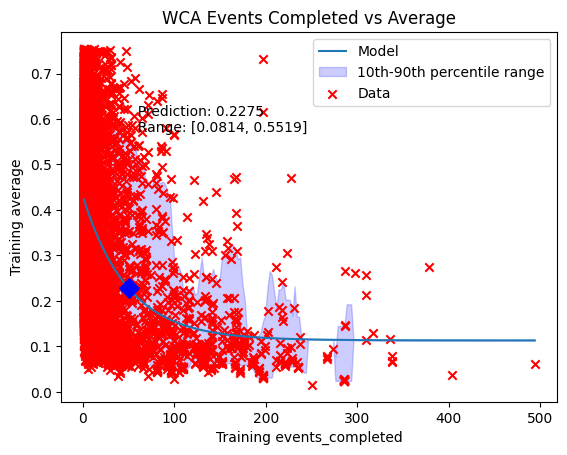

Predicted average for 50 events: 5.56s
Potential solving range: [2.12s, 13.20s]


In [ ]:
x_line = np.linspace(min(x), max(x), 200)
y_line = exp_func(x_line, a, b, c)

predict_val = 50

MIN_AVG = 200
MAX_AVG = 23750

def unscale(scaled_val):
    return scaled_val * (MAX_AVG - MIN_AVG) + MIN_AVG

upper_threshold = np.percentile(y, 95)
mask_clean = y <= upper_threshold
x_clean = x[mask_clean]
y_clean = y[mask_clean]

print(f"Removed {len(x) - len(x_clean)} outliers above {upper_threshold:.4f}")

y_prediction = exp_func(predict_val, a, b, c)

window = 10
nearby_mask = (x_clean >= predict_val - window) & (x_clean <= predict_val + window)
nearby_y = y_clean[nearby_mask]

while len(nearby_y) < 30 and window < 100:
    window += 10
    nearby_mask = (x_clean >= predict_val - window) & (x_clean <= predict_val + window)
    nearby_y = y_clean[nearby_mask]

if len(nearby_y) > 0:
    y_lower = np.percentile(nearby_y, 10)
    y_upper = np.percentile(nearby_y, 90)
else:
    y_lower = y_prediction - 0.05
    y_upper = y_prediction + 0.05

print(f"Using window ±{window}, found {len(nearby_y)} nearby points")

# Build band using cleaned data
y_lower_band = np.array([
    np.percentile(y_clean[(x_clean >= xv - window) & (x_clean <= xv + window)], 10)
    if np.sum((x_clean >= xv - window) & (x_clean <= xv + window)) >= 5
    else exp_func(xv, a, b, c)
    for xv in x_line
])
y_upper_band = np.array([
    np.percentile(y_clean[(x_clean >= xv - window) & (x_clean <= xv + window)], 90)
    if np.sum((x_clean >= xv - window) & (x_clean <= xv + window)) >= 5
    else exp_func(xv, a, b, c)
    for xv in x_line
])

plt.plot(x_line, y_line, label="Model")
plt.fill_between(x_line, y_lower_band, y_upper_band, alpha=0.2, color="blue", label="10th-90th percentile range")
plt.scatter(x_clean, y_clean, marker="x", c="r", label="Data")  # plot clean data
plt.scatter(predict_val, y_prediction, marker="D", c="blue", zorder=10, s=100)
plt.text(
    predict_val, y_upper + 0.02,
    f"  Prediction: {y_prediction:.4f}\n  Range: [{y_lower:.4f}, {y_upper:.4f}]",
)
plt.title("WCA Events Completed vs Average")
plt.ylabel(f"Training {training_data.columns[1]}")
plt.xlabel(f"Training {training_data.columns[0]}")
plt.legend()
plt.savefig("graph.png")
plt.show()

y_prediction_time = unscale(y_prediction)
y_lower_time = unscale(y_lower)
y_upper_time = unscale(y_upper)

print(f"Predicted average for {predict_val} events: {y_prediction_time/1000:.2f}s")
print(f"Potential solving range: [{y_lower_time/1000:.2f}s, {y_upper_time/1000:.2f}s]")